In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

In [2]:
df=pd.read_csv("D:/AML-Lab/Datasets/Salary_Data.csv")
df

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0
5,2.9,56642.0
6,3.0,60150.0
7,3.2,54445.0
8,3.2,64445.0
9,3.7,57189.0


In [3]:
print(df.info())
print(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes
None
       YearsExperience         Salary
count        30.000000      30.000000
mean          5.313333   76003.000000
std           2.837888   27414.429785
min           1.100000   37731.000000
25%           3.200000   56720.750000
50%           4.700000   65237.000000
75%           7.700000  100544.750000
max          10.500000  122391.000000


In [4]:
print(df.isnull().sum())
print(df.duplicated().sum())

YearsExperience    0
Salary             0
dtype: int64
0


In [5]:
X=df.drop('Salary',axis=1)
y=df['Salary']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)
print("Slope:", model.coef_[0])

Coefficients: [9423.81532303]
Intercept: 25321.583011776813
Slope: 9423.815323030976


In [9]:
X_train.head()

,YearsExperience
28,10.3
24,8.7
12,4.0
0,1.1
4,2.2


In [10]:
y_train.head()

28    122391.0
24    109431.0
12     56957.0
0      39343.0
4      39891.0
Name: Salary, dtype: float64

In [11]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(24, 1) (6, 1) (24,) (6,)


In [16]:
X_test

,YearsExperience
27,9.6
15,4.9
23,8.2
17,5.3
8,3.2
9,3.7


In [12]:
predictions = model.predict(X_test)

In [13]:
print("Predictions for new data:", predictions)

Predictions for new data: [115790.21011287  71498.27809463 102596.86866063  75267.80422384
  55477.79204548  60189.69970699]


In [18]:
#Print The Model Evaluation Metrics
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared (R2):", r2)

Mean Absolute Error (MAE): 6286.453830757749
Mean Squared Error (MSE): 49830096.85590839
Root Mean Squared Error (RMSE): 7059.04362190151
R-squared (R2): 0.9024461774180497


In [19]:
new_data = pd.DataFrame({'YearsExperience': [5, 10, 15]})
new_predictions = model.predict(new_data)

print("Predicted salaries for new data:")
for years, salary in zip(new_data['YearsExperience'], new_predictions):
    print(f"Years of Experience: {years}, Predicted Salary: {salary}")

Predicted salaries for new data:
Years of Experience: 5, Predicted Salary: 72440.6596269317
Years of Experience: 10, Predicted Salary: 119559.73624208657
Years of Experience: 15, Predicted Salary: 166678.81285724146


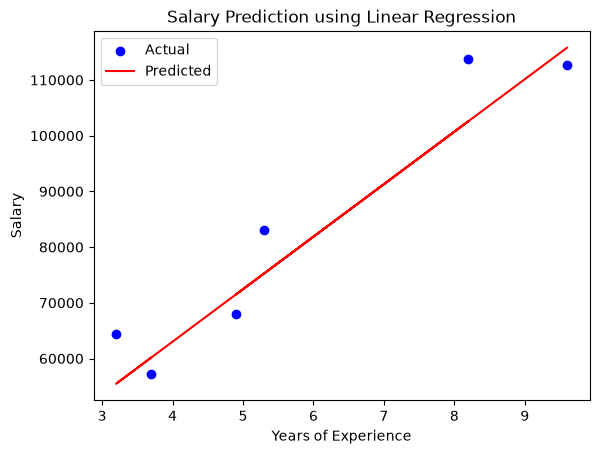

In [20]:
#Plot a Graph of the Test Data 
plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.plot(X_test, predictions, color='red', label='Predicted')
plt.title('Salary Prediction using Linear Regression')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.legend()
plt.show()

C:\Users\MSIS\AppData\Local\Temp\ipykernel_23392\2815535501.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


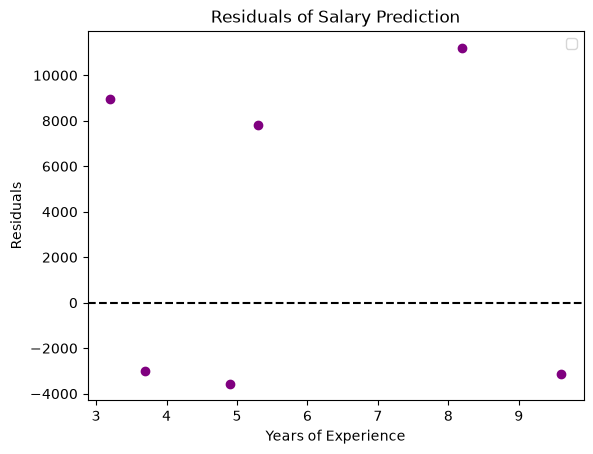

In [21]:
#Plot The Residual Graph
residuals = y_test - predictions

plt.scatter(X_test, residuals, color='purple')
plt.axhline(y=0, color='black', linestyle='--')
plt.title('Residuals of Salary Prediction')
plt.xlabel('Years of Experience')
plt.ylabel('Residuals')
plt.legend()
plt.show()